# 📊 EDA Analysis - Large Insurance Dataset (50,000 Records)
**Student:** Sanjay Thakor | **Roll No:** 220390107031

In this notebook I am doing Exploratory Data Analysis on a large insurance dataset with 50,000 records.
My goal is to understand the data, find patterns, and prepare it for machine learning.

## Cell 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Cell 2: Load Dataset

In [2]:
# Load the large insurance dataset
df = pd.read_csv('large_insurance_50000.csv')

print('✅ Dataset loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\nColumn Names: {list(df.columns)}')
print('\nFirst 5 rows:')
df.head()

✅ Dataset loaded successfully!
Shape: 50000 rows x 7 columns

Column Names: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,56,male,17.85,5,no,northwest,16099.70
1,46,female,34.56,2,no,northeast,13383.76
2,32,female,32.45,0,no,southeast,10409.40
3,60,female,21.33,2,yes,northeast,34974.00
4,25,female,39.53,0,no,southwest,11365.84


## Cell 3: Basic Info & Data Types

In [3]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Data Types ===')
print(df.dtypes)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       50000 non-null  int64  
 1   sex       50000 non-null  object 
 2   bmi       50000 non-null  float64
 3   children  50000 non-null  int64  
 4   smoker    50000 non-null  object 
 5   region    50000 non-null  object 
 6   charges   50000 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 2.7+ MB
None

=== Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## Cell 4: Check Missing Values & Duplicates

In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())

print(f'\n=== Duplicate Rows ===')
print(f'Total duplicates: {df.duplicated().sum()}')

print('\n✅ Data quality check complete!')

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

=== Duplicate Rows ===
Total duplicates: 0

✅ Data quality check complete!


## Cell 5: Statistical Summary

In [6]:
print('=== Statistical Summary (Numerical Columns) ===')
df.describe().round(2)

=== Statistical Summary (Numerical Columns) ===


,age,bmi,children,charges
count,50000.00,50000.00,50000.00,50000.00
mean,41.52,27.49,2.49,18410.38
std,13.83,7.21,1.71,9389.45
min,18.00,15.00,0.00,500.00
25%,30.00,21.22,1.00,12359.62
50%,41.00,27.54,2.00,15205.18
75%,54.00,33.75,4.00,19250.42
max,65.00,40.00,5.00,47788.09


## Cell 6: Categorical Columns Summary

In [7]:
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    print(f'\n--- {col.upper()} ---')
    print(df[col].value_counts())
    print(f'Percentage:')
    print((df[col].value_counts(normalize=True) * 100).round(2))


--- SEX ---
sex
female    25089
male      24911
Name: count, dtype: int64
Percentage:
sex
female    50.18
male      49.82
Name: proportion, dtype: float64

--- SMOKER ---
smoker
no     40152
yes     9848
Name: count, dtype: int64
Percentage:
smoker
no     80.3
yes    19.7
Name: proportion, dtype: float64

--- REGION ---
region
southwest    12573
southeast    12545
northeast    12461
northwest    12421
Name: count, dtype: int64
Percentage:
region
southwest    25.15
southeast    25.09
northeast    24.92
northwest    24.84
Name: proportion, dtype: float64


## Cell 7: Target Variable Distribution (Charges)

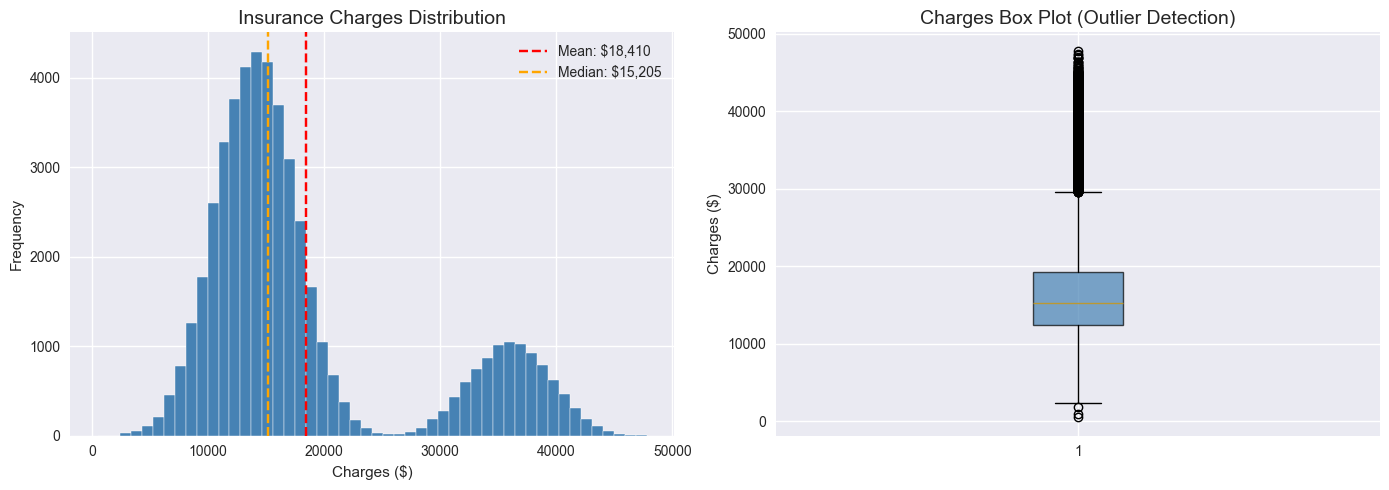

Min: $500.00
Max: $47,788.09
Mean: $18,410.38
Median: $15,205.18
Std Dev: $9,389.45


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['charges'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Insurance Charges Distribution', fontsize=14)
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['charges'].mean(), color='red', linestyle='--', label=f'Mean: ${df["charges"].mean():,.0f}')
axes[0].axvline(df['charges'].median(), color='orange', linestyle='--', label=f'Median: ${df["charges"].median():,.0f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['charges'], patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Charges Box Plot (Outlier Detection)', fontsize=14)
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

print(f'Min: ${df["charges"].min():,.2f}')
print(f'Max: ${df["charges"].max():,.2f}')
print(f'Mean: ${df["charges"].mean():,.2f}')
print(f'Median: ${df["charges"].median():,.2f}')
print(f'Std Dev: ${df["charges"].std():,.2f}')

## Cell 8: Numerical Features Distribution

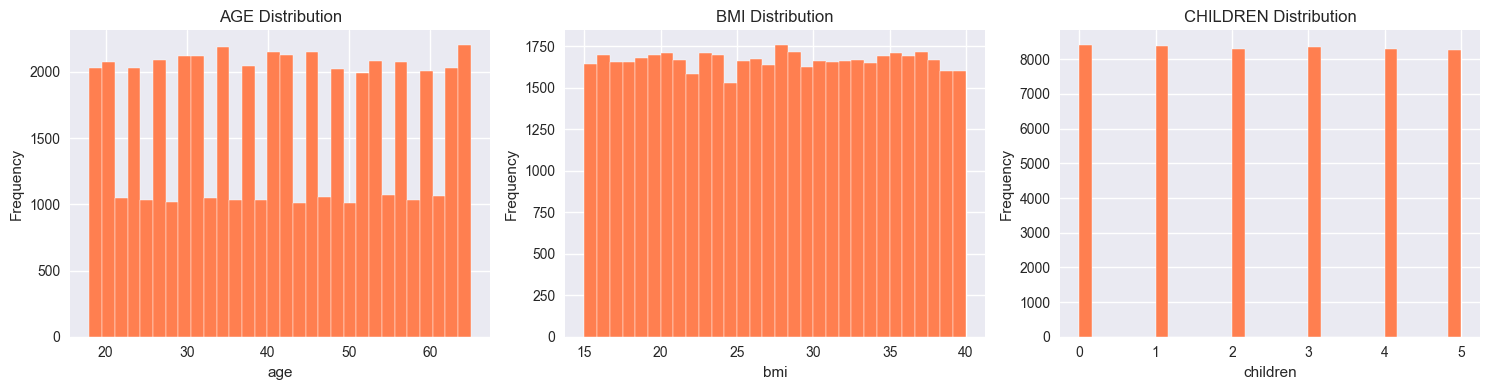

In [9]:
num_cols = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='coral', edgecolor='white')
    axes[i].set_title(f'{col.upper()} Distribution', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Cell 9: Categorical Features - Count Plots

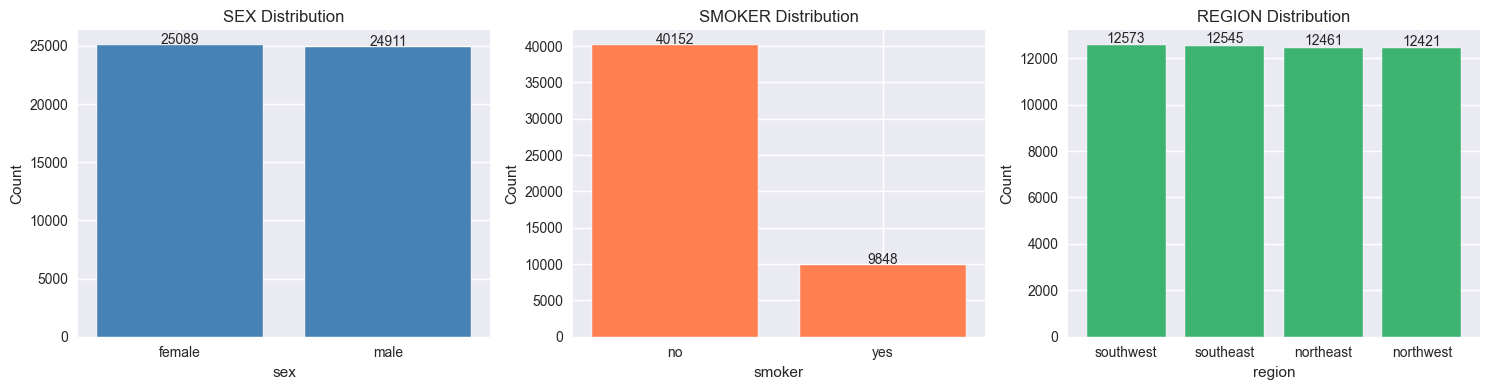

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cat_cols = ['sex', 'smoker', 'region']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='white')
    axes[i].set_title(f'{col.upper()} Distribution', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 100, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Cell 10: Smoking Impact on Charges

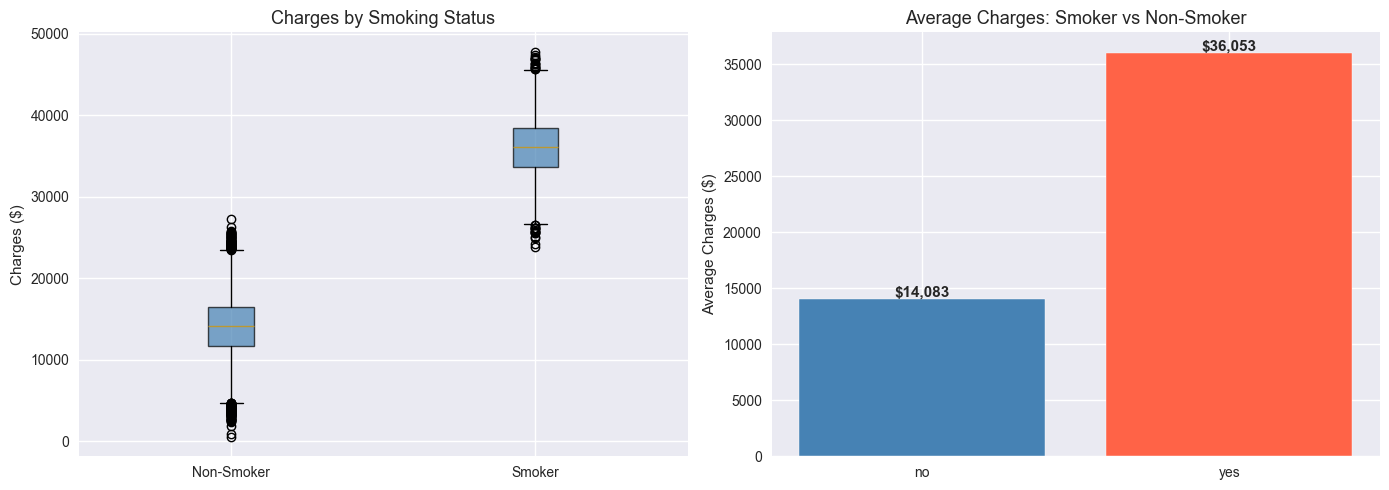

Non-Smoker Average: $14,083.29
Smoker Average:     $36,052.68
Difference:         $21,969.39
Smokers pay 156% more than non-smokers!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by smoker
smoker_yes = df[df['smoker'] == 'yes']['charges']
smoker_no  = df[df['smoker'] == 'no']['charges']

axes[0].boxplot([smoker_no, smoker_yes], labels=['Non-Smoker', 'Smoker'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Charges by Smoking Status', fontsize=13)
axes[0].set_ylabel('Charges ($)')

# Average bar chart
avg_charges = df.groupby('smoker')['charges'].mean()
bars = axes[1].bar(avg_charges.index, avg_charges.values,
                   color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Average Charges: Smoker vs Non-Smoker', fontsize=13)
axes[1].set_ylabel('Average Charges ($)')
for bar, val in zip(bars, avg_charges.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f'${val:,.0f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Non-Smoker Average: ${smoker_no.mean():,.2f}')
print(f'Smoker Average:     ${smoker_yes.mean():,.2f}')
print(f'Difference:         ${smoker_yes.mean() - smoker_no.mean():,.2f}')
pct = (smoker_yes.mean() / smoker_no.mean() - 1) * 100
print(f'Smokers pay {pct:.0f}% more than non-smokers!')

## Cell 11: Age vs Charges & BMI vs Charges

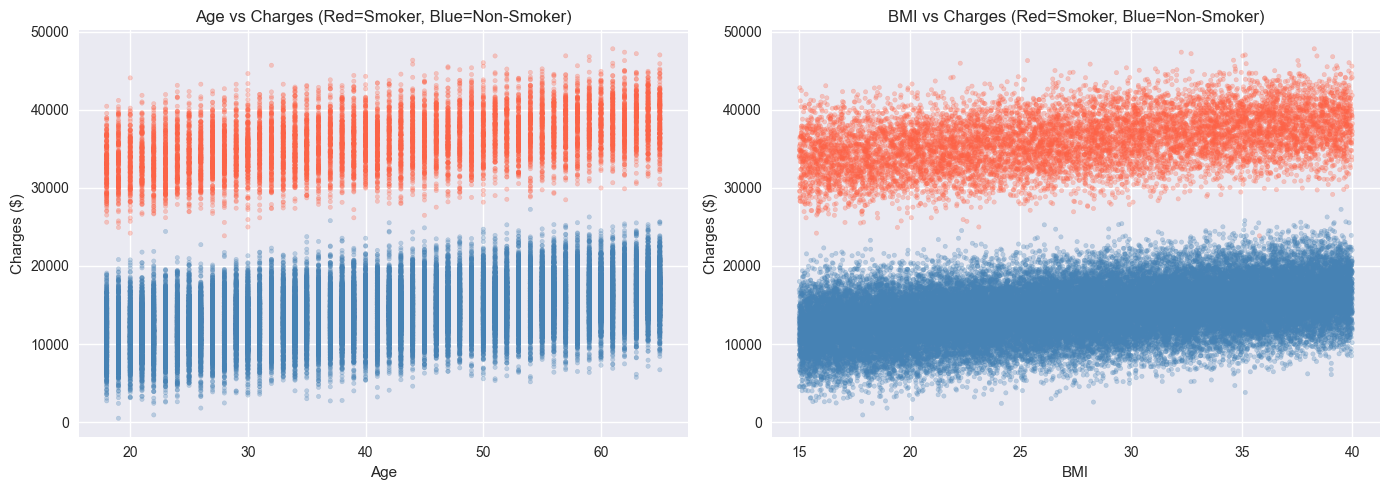

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})

# Age vs Charges
axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.3, s=10)
axes[0].set_title('Age vs Charges (Red=Smoker, Blue=Non-Smoker)', fontsize=12)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')

# BMI vs Charges
axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.3, s=10)
axes[1].set_title('BMI vs Charges (Red=Smoker, Blue=Non-Smoker)', fontsize=12)
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

## Cell 12: Charges by Region

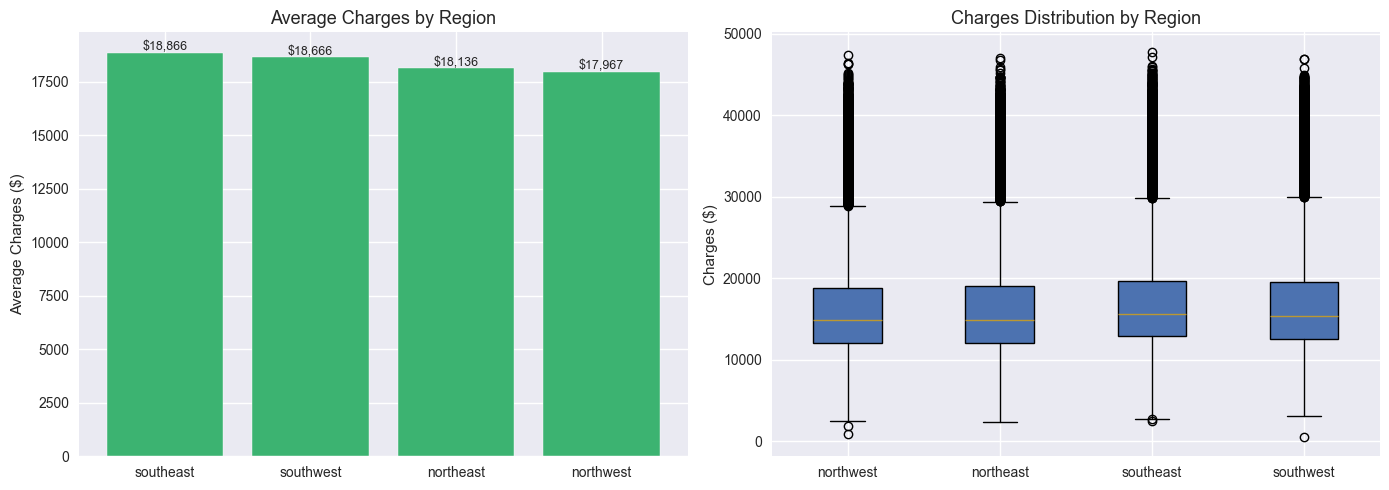

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average charges by region
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False)
axes[0].bar(region_avg.index, region_avg.values, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Average Charges by Region', fontsize=13)
axes[0].set_ylabel('Average Charges ($)')
for i, (reg, val) in enumerate(region_avg.items()):
    axes[0].text(i, val + 100, f'${val:,.0f}', ha='center', fontsize=9)

# Box plot by region
regions = df['region'].unique()
data_by_region = [df[df['region'] == r]['charges'].values for r in regions]
axes[1].boxplot(data_by_region, labels=regions, patch_artist=True)
axes[1].set_title('Charges Distribution by Region', fontsize=13)
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

## Cell 13: Correlation Heatmap

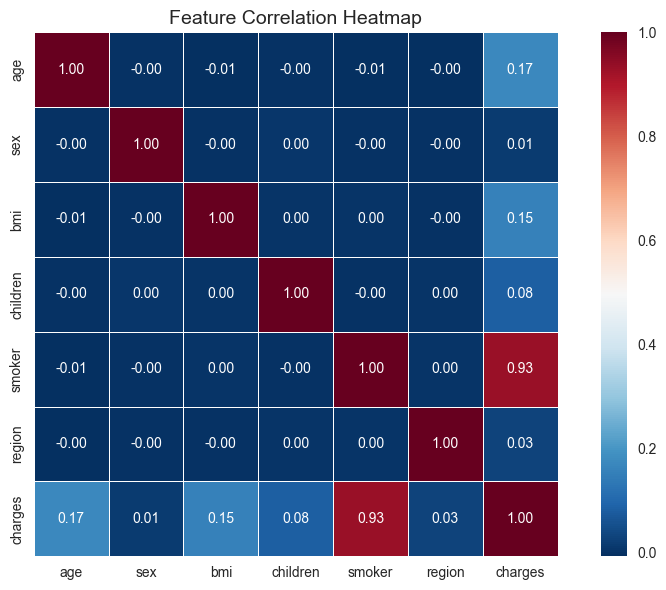


Correlation with Charges (sorted):
charges     1.000000
smoker      0.930551
age         0.169491
bmi         0.154742
children    0.080143
region      0.029615
sex         0.012121
Name: charges, dtype: float64


In [14]:
# Encode categorical for correlation
df_corr = df.copy()
df_corr['sex']    = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
df_corr['region'] = df_corr['region'].astype('category').cat.codes

corr = df_corr.corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelation with Charges (sorted):')
print(corr['charges'].sort_values(ascending=False))

## Cell 14: Children vs Charges

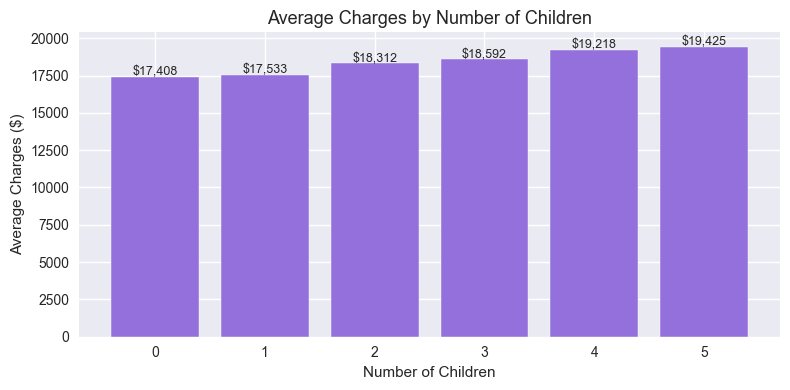

In [15]:
children_avg = df.groupby('children')['charges'].mean()

plt.figure(figsize=(8, 4))
plt.bar(children_avg.index, children_avg.values, color='mediumpurple', edgecolor='white')
plt.title('Average Charges by Number of Children', fontsize=13)
plt.xlabel('Number of Children')
plt.ylabel('Average Charges ($)')
for i, val in enumerate(children_avg.values):
    plt.text(i, val + 100, f'${val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Cell 15: EDA Summary & Key Findings

In [16]:
print('=' * 55)
print('       EDA SUMMARY - KEY FINDINGS')
print('=' * 55)
print(f'Total Records Analyzed : {len(df):,}')
print(f'Features               : {df.shape[1]}')
print(f'Missing Values         : {df.isnull().sum().sum()}')
print(f'Duplicate Records      : {df.duplicated().sum()}')
print()
print('--- Charges Summary ---')
print(f'Min Charge   : ${df["charges"].min():,.2f}')
print(f'Max Charge   : ${df["charges"].max():,.2f}')
print(f'Mean Charge  : ${df["charges"].mean():,.2f}')
print(f'Median Charge: ${df["charges"].median():,.2f}')
print()
print('--- Smoking Impact ---')
s_avg  = df[df['smoker']=='yes']['charges'].mean()
ns_avg = df[df['smoker']=='no']['charges'].mean()
print(f'Smoker Avg   : ${s_avg:,.2f}')
print(f'Non-Smoker   : ${ns_avg:,.2f}')
print(f'Difference   : {(s_avg/ns_avg - 1)*100:.0f}% higher for smokers')
print()
print('--- Top Correlations with Charges ---')
df_c = df.copy()
df_c['sex']    = df_c['sex'].map({'male':1,'female':0})
df_c['smoker'] = df_c['smoker'].map({'yes':1,'no':0})
df_c['region'] = df_c['region'].astype('category').cat.codes
corr_charges = df_c.corr()['charges'].drop('charges').sort_values(ascending=False)
for feat, val in corr_charges.items():
    print(f'  {feat:<12}: {val:.4f}')
print()
print('✅ EDA Complete! Ready for Preprocessing & Model Training.')

       EDA SUMMARY - KEY FINDINGS
Total Records Analyzed : 50,000
Features               : 7
Missing Values         : 0
Duplicate Records      : 0

--- Charges Summary ---
Min Charge   : $500.00
Max Charge   : $47,788.09
Mean Charge  : $18,410.38
Median Charge: $15,205.18

--- Smoking Impact ---
Smoker Avg   : $36,052.68
Non-Smoker   : $14,083.29
Difference   : 156% higher for smokers

--- Top Correlations with Charges ---
  smoker      : 0.9306
  age         : 0.1695
  bmi         : 0.1547
  children    : 0.0801
  region      : 0.0296
  sex         : 0.0121

✅ EDA Complete! Ready for Preprocessing & Model Training.
